In [42]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) # Para añadir /Users/hectorastudillo/py-proyects

# Verificamos que podamos trabajar con nuestra clase... debe de aparecer la carpeta en donde está contenido con lo que queremos trabajar
# for p in sys.path:
    # print(p)

# limpiar duplicados
sys.path = list(dict.fromkeys(sys.path))

import macro_analysis.macro_tools as macro_tools
import importlib
importlib.reload(macro_tools)

import pandas as pd

from macro_analysis.macro_tools import load_timeseries
from macro_analysis.macro_tools import synchronise_timseries_df
from macro_analysis.macro_tools import promedio_mensual
from macro_analysis.macro_tools import cargar_archivo
from macro_analysis.macro_tools import plot_normalized_timeseries
from macro_analysis.macro_tools import plot_timeseries
from macro_analysis.macro_tools import plot_two_timeseries

# Inflación + Expectativa
Una forma de analizar si realmente se cumplirá la expectativa de inflación sobre cierto año podría ser fijando la fecha de inicio (enero del año de interes/actual) e ir calculando su varianción conforme pasen los meses.
Esto lo logramos con la función load_timeseries especificando en este caso el parametro: 

*tipo_var = 'dec_base' el cual calcula la variación de cada mes vs enero del mismo año.*

In [43]:
data = 'INPC'
# En este caso, la columna del csv sobre la que queremos trabajar es 
columna_interes = 'INPC'
inflation_dec_base = load_timeseries(data, columna=columna_interes, tipo_var = 'dec_base')
inflation_dec_base

,Fecha,INPC,year,month,base,Var%
0,2018-01-01,98.795,2018,1,98.795,0.000000
1,2018-02-01,99.171,2018,2,98.795,0.380586
2,2018-03-01,99.492,2018,3,98.795,0.705501
3,2018-04-01,99.155,2018,4,98.795,0.364391
4,2018-05-01,98.994,2018,5,98.795,0.201427
...,...,...,...,...,...,...
93,2025-10-01,141.708,2025,10,137.949,2.724920
94,2025-11-01,142.645,2025,11,137.949,3.404157
95,2025-12-01,143.042,2025,12,137.949,3.691944
96,2026-01-01,143.588,2026,1,143.042,0.381706


La inflación puede ser clave dentro de las tasas de referencia...
# Mi hipótesis - SE RECHAZÓ 
Analizar la diferencia entre la tasa de referencia expuesta por banxico y la suma de la inflación + retorno UDIBONOS que se asemeja a la tasa real, tal que la diferencia ideal debe de ser cercana a 0 con desviaciones de hasta 1% aceptables.
De no ser así podría verse afectada la inversión a México...

Para ello necsitamos calcular...
* Tasa de referencia MENSUAL, BANXICO publica la tasa de referencia diariamente.
* La variación en la inflación del mes vs la del año anterior
* Tasas reales del mes... 

Se dice por la ecuación de Fisher que 
*tasa_referencia = inflación + tasa_real*
Sin embargo, para poder analizar realmente la situación de inversión en México, tomaremos la tasa de UDIBONOS como la tasa real...
TASAS_UDIBONOS - Columna 3_AÑOS


In [28]:
# Podemos acceder a la información de la siguiente manera:
inflacion = load_timeseries('INPC', columna= 'INPC', tipo_var = 'yoy')

tasa_real = load_timeseries('TASAS_UDIBONOS', columna = '3_AÑOS')

# inflación + tasa real
# Dado que queremos usar los df´s que hemos creado en este bloque de codigo, definiremos en la sigunte función csv = False
infl_mas_real = synchronise_timseries_df(inflacion, tasa_real, 'Var%', '3_AÑOS', suma = True, csv = False)

ref_data = load_timeseries('refRateMX', columna = 'Tasa')

tasa_ref = promedio_mensual(ref_data, 'Tasa')

dif_fisher = synchronise_timseries_df(infl_mas_real, tasa_ref, 'Suma', 'Tasa', dif = True, csv = False)

dif_fisher

,Fecha,Suma,Tasa,Diferencia
0,2019-01-01,8.665606,8.250000,0.415606
1,2019-02-01,8.120668,8.250000,-0.129332
2,2019-03-01,8.164342,8.250000,-0.085658
3,2019-04-01,8.453292,8.250000,0.203292
4,2019-05-01,8.202078,8.250000,-0.047922
...,...,...,...,...
79,2025-10-01,7.556521,7.500000,0.056521
80,2025-11-01,7.989191,7.300000,0.689191
81,2025-12-01,8.041944,7.145161,0.896783
82,2026-01-01,7.961301,7.000000,0.961301


# Tasas de referencia + Expectativa.

Sin embargo podemos empezar a analizar además la diferencia entre las tasas de referencia de México y EUA, **dado que la información que se publica es diaria** podemos implementar una función que saque un promedio mensual de la tasa de referencia publicada por ambas economías... y trabajar sobre ellas.

La función podrá permitir información semanal.

In [30]:
# Promedio mensual y semanal - MX y USA
ref_data_MX = load_timeseries('refRateMX', columna = 'Tasa')
tasa_ref_MX = promedio_mensual(ref_data_MX, 'Tasa')

ref_data_USA = load_timeseries('refRateUSA', columna = 'Tasa')
tasa_ref_USA = promedio_mensual(ref_data_USA, 'Tasa')

# Diferencia
dif_ref_rates = synchronise_timseries_df(tasa_ref_MX, tasa_ref_USA, 'Tasa', 'Tasa', 'MX_rate', 'USA_rate', dif = True, csv = False)


Con ello ya podemos empezar a añadir la diferencia entre estos instrumentos monetarios a nuestros análisis **Y LA EXPECTATIVA QUE SE TIENE**

*En este caso la expectativa ayudaría bastante para MARCAR UN HORIZONTE del instrumento a verse afectado.*

## Análisis
Para realizar nuestros análisis utilizaremos la siguiente función:
*plot_normalized_timeseries*
Pero para ello ocupamos transformar nuestros df previamente creados a un csv, eso lo podemos lograr con la siguiente función:
*cargar_archivo*

Para mantener las fechas y evitar un mal manejo de ellas... creamos 3 csv

### Mi hipótesis - SE RECHAZÓ
### CASO 2024
A mitades del 2024... el dolar frente al peso mexicano se vió favorecido, devaluandose el peso mexicano... hasta este punto lo natural sería preguntarse... la inflación y/o las tasas de referencia tanto de México de manera individual (información de df_fisher) como de manera conjunta con las de EUA (información de dif_ref_rates)... tuvieron que ver con este acontecimiento

*Nota: podríamos agregar real yields = nominal - inflación esperada pero se dice que iShares TIPS Bond ETF, TIPS (bonos protegidos contra inflación), este ETF refleja real yields directamente*


Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/inflation_dec_base.csv
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/ref_rate_adecuada.csv
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/dif_refRateMXUSA.csv


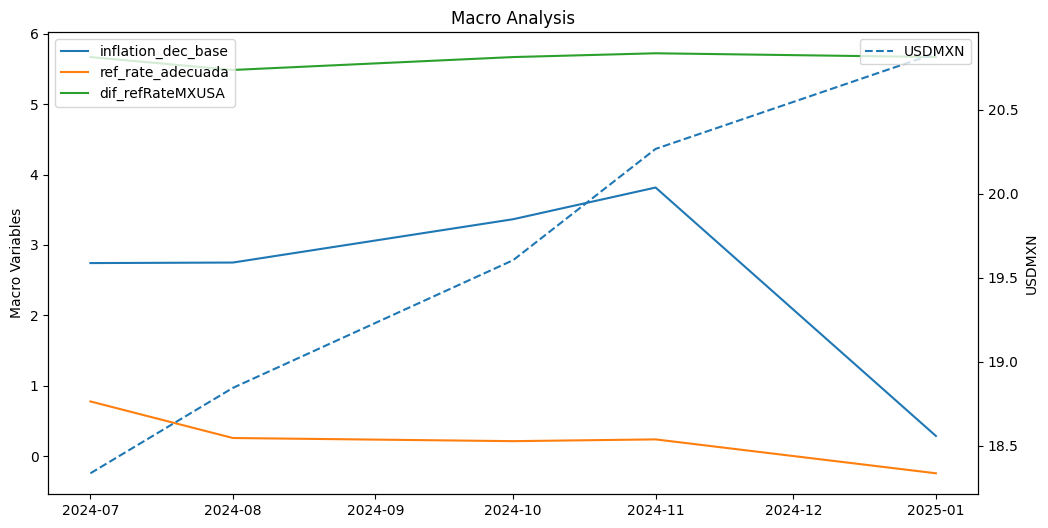

In [31]:
cargar_archivo(inflation_dec_base, 'inflation_dec_base')
cargar_archivo(dif_fisher, 'ref_rate_adecuada')
cargar_archivo(dif_ref_rates, 'dif_refRateMXUSA')

import pandas as pd
import matplotlib.pyplot as plt

def analisis_inflacion_references(
    rics, columnas,
    from_date=None, to_date=None
):
    
    dfs = []

    # Cargar datos
    for ric, col in zip(rics, columnas):
        df = load_timeseries(ric, columna=col)
        df = df[['Fecha', col]].copy()
        df = df.rename(columns={col: ric})
        dfs.append(df)

    # Merge por fecha
    t = dfs[0]
    for df in dfs[1:]:
        t = pd.merge(t, df, on='Fecha', how='inner')

    # Filtrado de fechas 
    t['Fecha'] = pd.to_datetime(t['Fecha'])

    if from_date:
        t = t[t['Fecha'] >= from_date]
    if to_date:
        t = t[t['Fecha'] <= to_date]

    if t.empty:
        print("No data available in selected range")
        return

    # Plot
    fig, ax1 = plt.subplots(figsize=(12,6))

    # Primeras 3 series (misma escala)
    for ric in rics[:3]:
        ax1.plot(t['Fecha'], t[ric], label=ric)

    ax1.set_ylabel('Macro Variables')
    ax1.legend(loc='upper left')

    # Segunda escala (USDMXN)
    ax2 = ax1.twinx()
    ax2.plot(t['Fecha'], t[rics[3]], linestyle='--', label=rics[3])
    ax2.set_ylabel('USDMXN')

    ax2.legend(loc='upper right')

    plt.title('Macro Analysis')
    plt.show()

rics = ['inflation_dec_base', 'ref_rate_adecuada', 'dif_refRateMXUSA', 'USDMXN']
columnas = ['Var%', 'Diferencia', 'Diferencia', 'Cierre']

analisis_inflacion_references(
    rics,
    columnas,
    from_date='2024-06-01',
    to_date='2025-01-01'
)

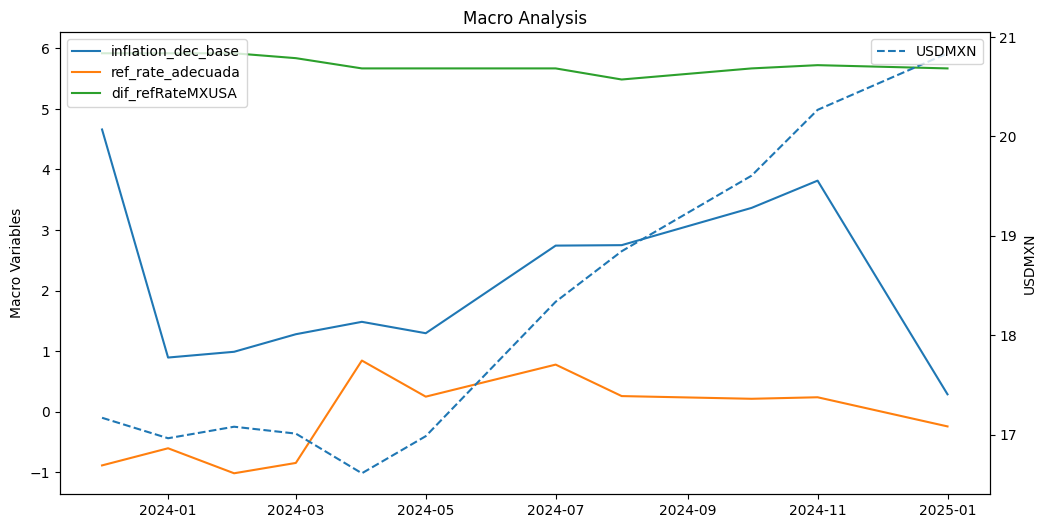

In [166]:
analisis_inflacion_references(
    rics,
    columnas,
    from_date='2023-12-01',
    to_date='2025-01-01'
)

Obsevamos que:
* La inflación no superó el 4%
* La tasa de referencia de México se mantuvo atractiva (por encima de 0 ofreciendo 6% más aproximadamente que EUA) **pero no constante!** al menos hubo un cambio en su tasa donde bajó 0.25 puntos... lo cual puede afectar al peso directamente a pesar de ser un cambio pequeño, este cambio se ve producido en *2024-04* pero puede no ser suficiente evidencia del fortalecimiento del dolar.
* La tasa de refencia de México era la adecuada (la linea naranja se mantiene cercana a 0 **cuando el dolar se empezó a fortalecer**)

Entonces estos conceptos de inflación y tasa de referencia NO muestran suficiente evidencia de haber afectado directamente la devaluación del peso SOBRE ESTE CASO DE 2024...

Y ES QUE AÚN CON RUMORES, EXPECTATIVA DE AMBOS CONCEPTOS, INFLACIÓN Y TASAS DE REFERENCIA, no habría evidencia aún.

**PERO NO PODEMOS DESCARTAR AMBOS CONCEPTOS Y SU IMPACTO SOBRE EL USDMXN**, sería incorrecto decir que en absoluto y como caso general estos conceptos no afecten el peso.

### CASO 2020 - Pandemia 
Analicemos otro caso en donde el dolar se vió a la alza... tras la pandemia, veamos si podemos encontrar evidencia con la inflación y las tasa de referencia que expliquen el fortalecimiento del dolar...

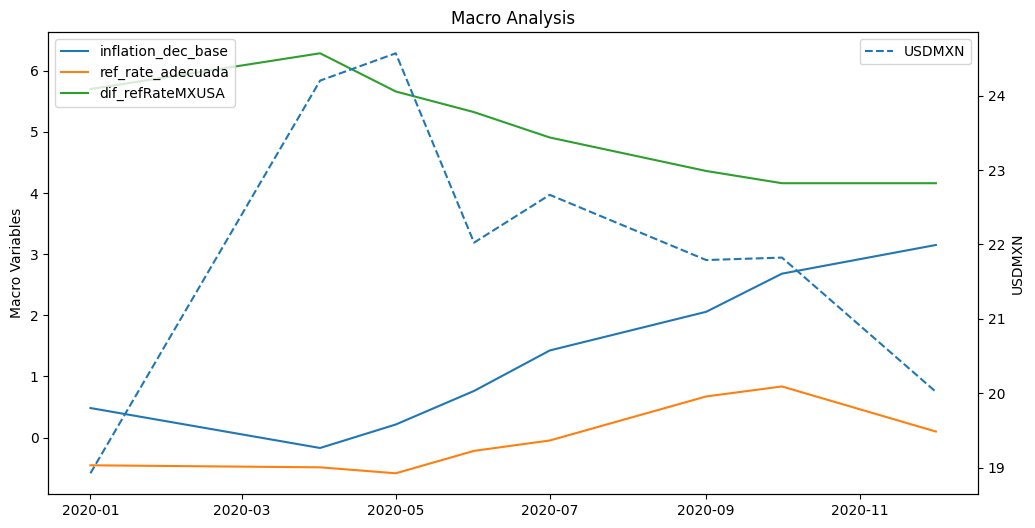

In [173]:
analisis_inflacion_references(
    rics,
    columnas,
    from_date='2020-01-01',
    to_date='2020-12-31'
)

In [ ]:
rics = ["DXY","TNX", "US02Y", "GOLD", "NASDAQC", "TLT", 'USDMXN']
plot_normalized_timeseries(
    rics,
    from_date="2020-01-01",
    to_date='2020-06-01',
    base_value=100
)

**Lo que si pudo haber afectado pasa al concepto de BONOS e inversión extranjera.**

# Bonos

Un TIPS (Treasury Inflation-Protected Security) es:
Un bono gubernamental (instrumento de deuda) emitido por el Tesoro de EE.UU. cuyo valor principal está indexado a la inflación (CPI), pagan cupones reales (tasa fija sobre un principal que cambia).
Su equivalente en México, los UDIBONOS, funcionan bajo la misma lógica.
**Ambos representan la tasa de interés real del mercado.**


**Definición**:

*Tightening Global Real*... Se refiere a cuando los bancos centrales actúan simultáneamente para reducir la cantidad de dinero circulante en la economía y elevar los tipos de interes.

Bajo esta idea... se buscaría una clara tendencia en donde:
* ETF de TIPS que muestra el precio de compra de este bono tienda a la baja
* ETF TLT que muestra el precio compuesto por bonos del Tesoro estadounidense de largo plazo, específicamente aquellos con vencimientos restantes **SUPERIORES a 20 años** (T bonds) de la misma manera con una tendencia a la baja
Tiende a un resultado en donde el índice DXY va a la alza... 

**Definición**:

*DXY* es un índice financiero que mide el valor del dólar estadounidense frente a una canasta de seis divisas extranjeras principales, funciona como un indicador clave de la fortaleza o debilidad del dólar en los mercados globales. El índice se pondera contra seis divisas principales: Euro (EUR, 57.6%), Yen japonés (JPY, 13.6%), Libra esterlina (GBP, 11.9%), Dólar canadiense (CAD, 9.1%), Corona sueca (SEK, 4.2%) y Franco suizo (CHF, 3.6%).
Si el DXY sube, indica que el dólar se fortalece frente a estas divisas. Si baja, el dólar se debilita.

Pero, ¿se cumple dentro de los escenarios previamente estudiados? (2020 y 2024)

*Observemos que este índice no está correlacionado con el dolar frente al peso méxicano (USDMXN), este tiende a correlacionarse cuando hay volatilidad GLOBAL alta, yields USD alta, IMPACTO GLOBAL QUE PROVOQUE LA BÚSQUEDA DE REFUGIO EN EL DOLAR, pasando a afectar indirectamente a México ya que salen flujos y de ahí provocando la ruptura del carry trade que produce México al tener tasas más atractivas generalmente y bajo este escenario el USDMXN se ALÍNEA, MÁS NO SE CORRELACIONA con el índice DXY*, por eso es natural ver bajo nuestro modelo de regresión una correlación cercana a 0, y bajo sus timeseries alineaciones en ciertos periodos.

Entonces:

Se dice que USDMXN NO sigue al DXY cuando:
* Hay carry alto en MXN... PERO QUE TAN ALTO? 
    Es bien sabido que las tasa de interés de México son mucho más altas que las de EUA, se esperaría erroneamente bajoe esta última idea que el dolar se mantuviera débil frente al peso mexicano.
    Este esecenario recordemos que significa que el peso mexicano ofrece una ganancia atractiva y alta por diferencial de tasas de interés comparado con otras monedas (como el yen o dólar). Los inversores piden prestado en monedas de bajo interés para comprar pesos e invertirlos en instrumentos mexicanos, ganando la diferencia.
* Y entonces flujos entran a México

PERO sí se alinea cuando:

* Se rompe el “carry trade”
Ejemplo:
* Volatilidad ALTA
* Yields US ALTA
* Riesgo **GLOBAL** ALTA, no solo en México.
Entonces:
* Salen flujos de MXN
* USDMXN sube MÁS que DXY


**Definición**:

*El carry trade* (o bicicleta financiera) es una estrategia de inversión que consiste en pedir prestado dinero en una divisa con tipos de interés bajos (ej. Yen japonés) para invertirlo en otra divisa con tipos de interés altos (ej. Dólar australiano o emergentes), buscando ganar la diferencia entre ambos intereses. El beneficio se obtiene si el tipo de cambio se mantiene estable o favorece al inversor.

Entonces... 
* TIPS ETF - Muestra precios de un bono.
* TLT ETF - Muestra precios de un conjunto de bonos (de los T bonds).
* Ambos se pueden ver afectados a la vez a la baja y podríamos notar que el índice DXY tiende a la alza PORQUE TASAS REALES ALTAS ENTONCES DOLAR A LA ALZA, y por "propiedad" de los bonos, cuando el yield aumenta, los precios bajan. 
**“Prefiero invertir en EE.UU. porque me paga más en términos reales”**
¿Cómo era la tasa real en pandemia?, Y bajo el intervalo de crisis en donde bajó el precio del oro?
Podría ser que las tasas reales no hayan subido, ni bajado
Y el hecho de que haya subidoen general el dolar fue por pánico, y el dolar como normalmente lo es, el refugio 

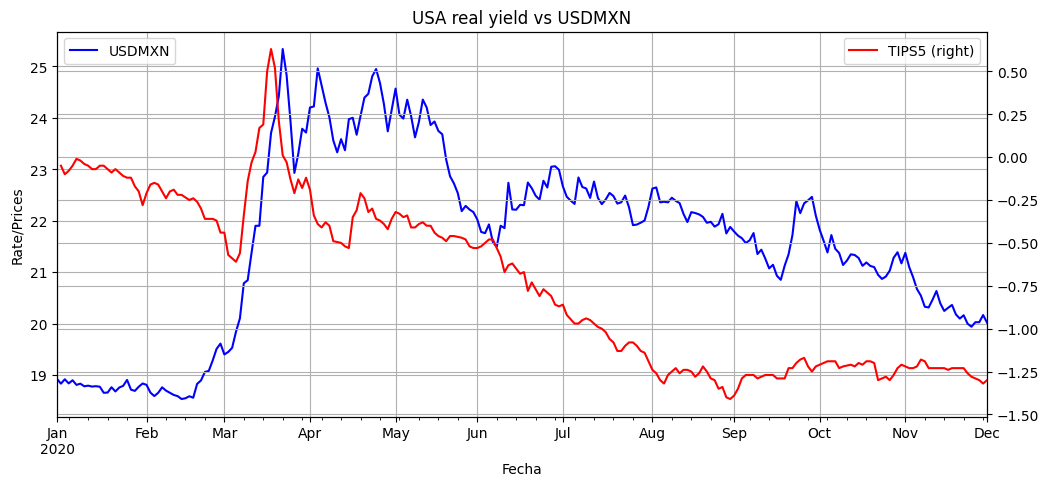

In [32]:
# Graficar tasa real de EUA en 2020 y 2024, y su comportamiento de forma general PARA VER SI HAY PERIODOS DE MATCH CON DXY, usar TIPS a 5 y 10 años.
# Ir viendo si hay insights interesantes con los datos de MX es decir UDIBONOS a 3 y 10 años.
real_yield_usa = load_timeseries('TIPS5', columna = 'Tasa')
real_yield_mx = load_timeseries('UDIBONOS3', columna = 'Tasa')

# Real yield de usa "suavizado" mensuamente 
# monthly_real_yield_usa = promedio_mensual(real_yield_usa, 'Tasa')

# plot_two_timeseries(real_yield_usa, real_yield_mx, 'Tasa', 'Tasa', titulo = 'Daily real yield timeseries USA vs MX')
# plot_two_timeseries(monthly_real_yield_usa, real_yield_mx, 'Tasa', 'Tasa',  titulo = 'Monthly USA Real Yield vs Daily MX Timeseries')

# Dolar
DXY = load_timeseries('DXY', columna = 'Cierre')
USDMXN = load_timeseries('USDMXN', columna = 'Cierre')
plot_two_timeseries('USDMXN', 'TIPS5', 'Cierre', 'Tasa', from_date='2020-01-01', to_date='2020-12-01', titulo = 'USA real yield vs USDMXN')


México siempre tendrá una tasa real más alta que México, pero eso no implicitamente significa buenas noticias de forma constante y continua, que el peso nunca devalue o cosas por el mismo estilo.

La clave esta en DXY, en este caso el USDMXN muestra como el peso devaluó principalmente ante la noticia de COVID **y el pánico temporal que causó**
El hecho de decir "pánico temporal generado" se puede confirmar por la evolución del peso conforme al cierre del año (no mantuvo constante su devaluación a lo largo del año)

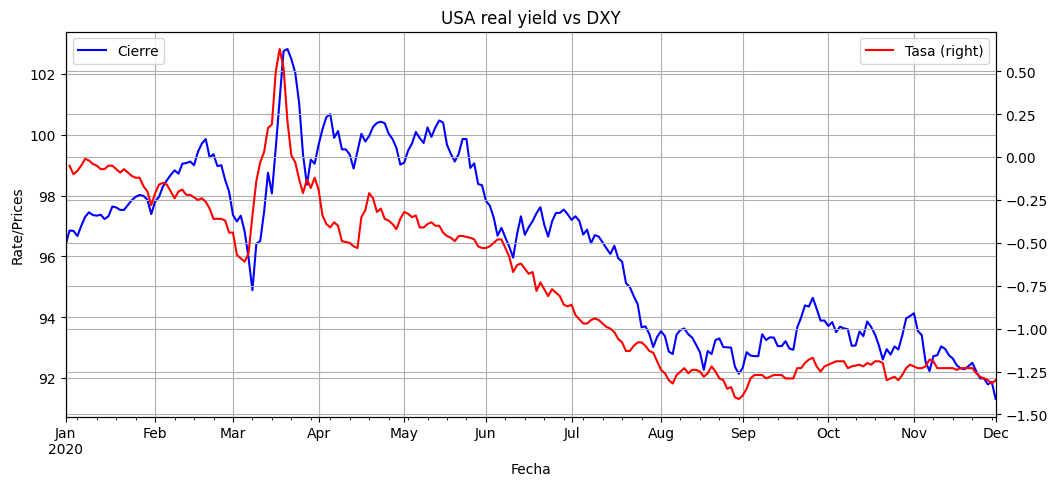

In [68]:
plot_two_timeseries('DXY', 'TIPS5', 'Cierre', 'Tasa', from_date='2020-01-01', to_date='2020-12-01', titulo = 'USA real yield vs DXY')

### TNX y CEBOE - Mercado
El previo análisis nos lleva a **TNX** - símbolo bursátil del Índice de rendimiento de los bonos del Tesoro a 10 años (CBOE 10-Year Treasury Note Yield)
El cual el Bono M a 10 años es su equivalente en México.
Ambos representan la tasa de interes NOMINAL.

Respecto a la información que tenemos de TNX gracias a Investing.com, es clave mencionar lo siguiente:
El ticker CBOE 10-Year Treasury Note Yield Index (TNX) NO es un ETF ni un activo invertible.
Es un índice de rendimiento (yield) que refleja la tasa del bono del Tesoro de EE.UU. a 10 años.

**CBOE es UN MERCADO, asi como BMV para México, NO es un bono, CBOE crea índices como:**
* CBOE 5-Year Treasury Note Yield Index (FVX)
* CBOE 10-Year Treasury Note Yield Index (TNX)

PERO
El CBOE 10-Year Treasury Note Yield Index (TNX) ES una representación del yield de los **U.S. Treasury Note**

* **El TNX en investing.com está expresado como yield × 10**
Entonces:
Si ves 44.40, en realidad significa 4.44%
TNX = tasa (yield)
----

Recordemos ademas la relación inversa que existe en todo bono respecto a su precio con el yield que ofrecen...
Si el precio sube entonces el yield baja y viceversa, entonces
Si sube el yield (TNX ↑ - yield de T note) entonces  TLT baja - precios de T bonds
Si baja el yield (TNX ↓) entonces TLT sube

Entonces, debemos de quedarnos con la idea clave de que TNX no muestra precios, si no que rendimientos de un T note a 10 años en % PERO QUE DEBEMOS DE TRANSFORMAR Y NO USAR DE FORMA DIRECTA, y que este representa la tasa NOMINAL del mercado...

**FVX** (CBOE 5-Year Treasury Note Yield Index) es la misma idea que TNX pero a 5 años.

Trabajemos de forma limpia directamente consultando los datos de los rendimientos de los U.S. Treasury Note, a 5 o 10 años. CGS5

Intuitivamente nos llevará al concepto de Inflación.
----
Hay que diferenciar la información correctamente...
DGS5 VS US T NOTES
“DGS5 es el yield (tasa) de los T-Notes a 5 años en madurez constante”
DGS5 sí representa el rendimiento de los United States Treasury Note (5‑Year), pero no es el rendimiento de un bono específico: es una tasa de referencia construida.
Aunque están estrechamente relacionados, CGS5 (o GS5/DGS5) y los US 5-Year Treasury Notes no son exactamente lo mismo. La diferencia principal radica en que uno es un indicador de mercado y el otro es el activo físico o instrumento financiero en sí.

----
* Market Yield on U.S. Treasury Securities at 5-Year Constant Maturity, Quoted on an Investment Basis, Inflation-Indexed (DFII5) = TIPS a 5 años = Real yield - Diario
* Market Yield on U.S. Treasury Securities at 5-Year Constant Maturity, Quoted on an Investment Basis (DGS5) = Nomial yield - Diario 
* Bono a tasa fija corresponde a los Bonos M - Mensual
* UDIBONOS - Diaria

La información diaria pasar por el proceso de promedio mensual.

In [37]:
# Para EUA 
real_yield_usa = load_timeseries('TIPS5', columna = 'Tasa') # Puede ser de 5, 10 años

nominal_yield_usa = load_timeseries('DGS5', columna = 'Tasa')


# Para MX
real_yield_mx = load_timeseries('UDIBONOS3', columna = 'Tasa') # Puede ser de 3,10,30 años
nominal_yield_mx = load_timeseries('BONOM3', columna = 'Cierre') # Puede ser de 5, 10 años
# load_timeseries(info1, columna=columna)


## Inflación esperada
Se dice que en finanzas, se suele trabajar a largo plazo, y con esto nos referimos a que para poder trabajar y entender la inflación esperada trabajamos con temporalidades superiores a los 3 años... como 5 y 10 normalmente, lo que equivale a trabajar con los T notes... 
Entonces, bajo esta idea y este concepto, estaremos trabajando con los RENDIMIENTOS (yields) de los T notes a 5 años y 10 años, equivalente a los Bonos M de 5 a 10 años para el caso de México. 

          Fecha  TIPS5  DGS5  Diferencia
0    2018-01-02   0.35  2.25       -1.90
1    2018-01-03   0.38  2.25       -1.87
2    2018-01-04   0.35  2.27       -1.92
3    2018-01-05   0.34  2.29       -1.95
4    2018-01-08   0.38  2.29       -1.91
...         ...    ...   ...         ...
2052 2026-03-20   1.38  4.01       -2.63
2053 2026-03-23   1.42  3.95       -2.53
2054 2026-03-24   1.48  4.03       -2.55
2055 2026-03-25   1.45  3.96       -2.51
2056 2026-03-26   1.52  4.08       -2.56

[2057 rows x 4 columns]
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/macro_data/EXP_INF_USA5PRUEBAAAAAA.csv


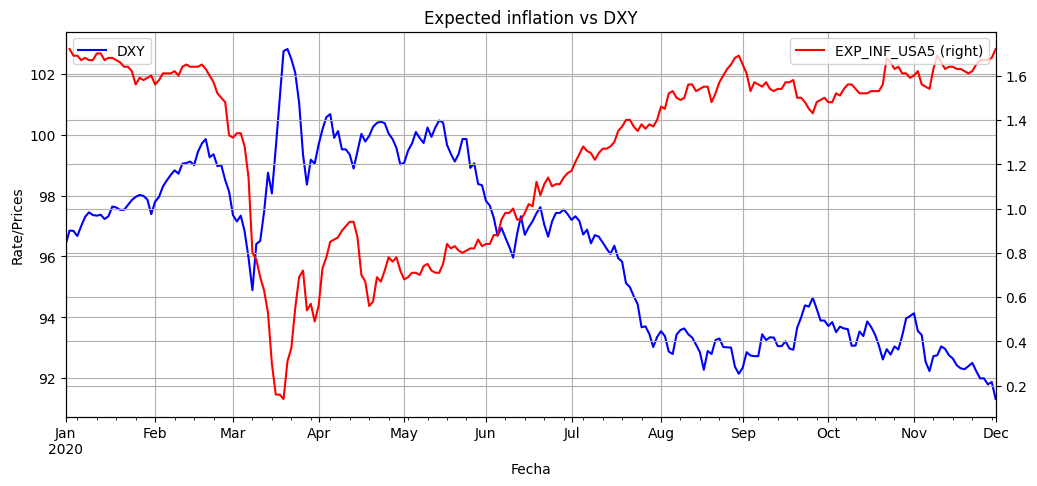

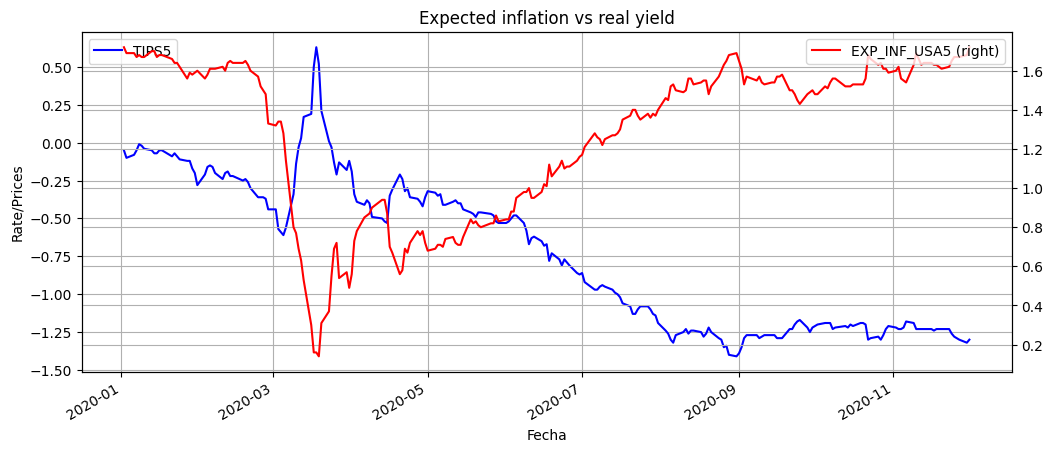

In [41]:
# Dado que nuestra información ya está cargada como un dataframe, definimos csv = False
expected_inflation_usa = synchronise_timseries_df('TIPS5', 'DGS5', 'Tasa', 'Tasa', dif = True)
print(expected_inflation_usa)
expected_inflation_mx = synchronise_timseries_df('TIPS5', 'DGS5', 'Tasa', 'Tasa', dif = True)

# GUARDO LA INFOPRMACIÓN PARA PODERLA USAR EN ALGÚN ALGÚN ANÁLISIS POR PERIODO
cargar_archivo(expected_inflation_usa, archivo = 'EXP_INF_USA5PRUEBAAAAAA')

# Análisis bajo periodo de COVID
plot_two_timeseries('DXY', 'EXP_INF_USA5', 'Cierre', 'Diferencia', from_date='2020-01-01', to_date='2020-12-01', titulo = 'Expected inflation vs DXY')
plot_two_timeseries('TIPS5', 'EXP_INF_USA5', 'Tasa', 'Diferencia', from_date='2020-01-01', to_date='2020-12-01', titulo = 'Expected inflation vs real yield')


### Esperanza de inflación inplicita derivada de un periodo de 10 años...


          Fecha  DGS10  TIPS10  Diferencia  exp_inf
0    2018-01-02   2.46    0.46        2.00     2.00
1    2018-01-03   2.44    0.46        1.98     1.98
2    2018-01-04   2.46    0.45        2.01     2.01
3    2018-01-05   2.47    0.46        2.01     2.01
4    2018-01-08   2.49    0.47        2.02     2.02
...         ...    ...     ...         ...      ...
2052 2026-03-20   4.39    2.01        2.38     2.38
2053 2026-03-23   4.34    2.01        2.33     2.33
2054 2026-03-24   4.39    2.06        2.33     2.33
2055 2026-03-25   4.33    2.02        2.31     2.31
2056 2026-03-26   4.42    2.08        2.34     2.34

[2057 rows x 5 columns]
Archivo guardado en: /Users/hectorastudillo/py-proyects/financial_risk_analysis/macro_analysis/EXP_INF_USA10.csv


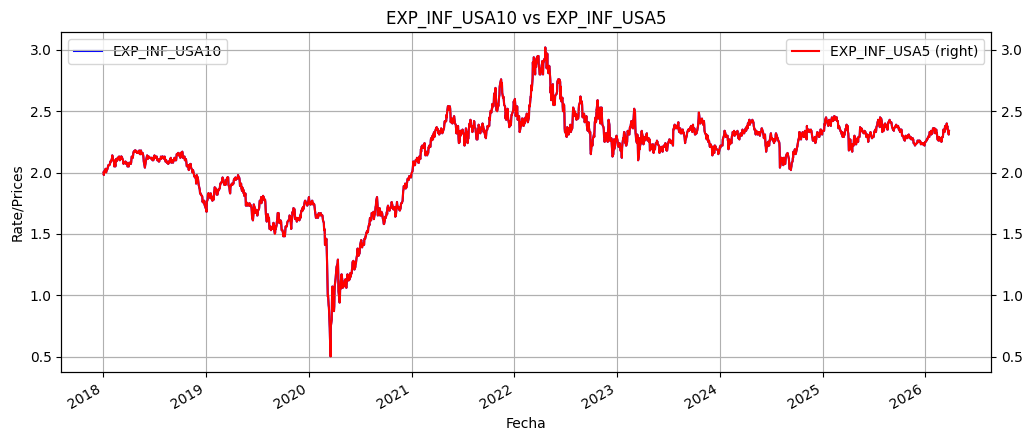

<Figure size 640x480 with 0 Axes>

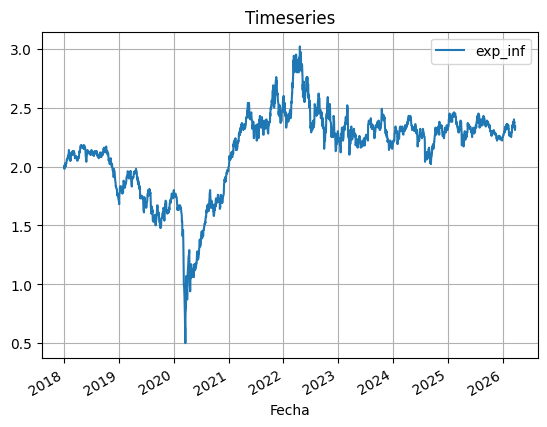

In [34]:
# Dado que nuestra información ya está cargada como un dataframe, definimos csv = False
expected_inflation_usa = synchronise_timseries_df('DGS10', 'TIPS10', 'Tasa', 'Tasa', dif = True)
expected_inflation_usa['exp_inf'] = expected_inflation_usa['Diferencia']
print(expected_inflation_usa)

# GUARDO LA INFOPRMACIÓN PARA PODERLA USAR EN ALGÚN ALGÚN ANÁLISIS POR PERIODO
cargar_archivo(expected_inflation_usa, archivo = 'EXP_INF_USA10')

plot_two_timeseries('EXP_INF_USA10', 'EXP_INF_USA5', 'Diferencia', 'Diferencia', titulo = "EXP_INF_USA10 vs EXP_INF_USA5")
plot_timeseries('EXP_INF_USA10', 'exp_inf')

En este caso trabajaremos con los rendimientos del bono de EUA a 5 años y los rendimientos del bono de MX a 5 años
Calcularemos su diferencia
* Esto indicaría el premio por invertir en México.
* Con ello además podemos trabajar con la información de CDS = Credit Default Swap que mide el riesgo de un país y te protege si el país en cuestión incumple.

In [157]:

info1 = 'BONOMX5'
info2 = 'BONOUSA5'
columna = 'Cierre'
df = synchronise_timseries_df(info1, info2, columna, columna, dif = True)
print(df)

          Fecha  BONOMX5  BONOUSA5  Diferencia
0    2018-01-02     7.51     2.248       5.262
1    2018-01-03     7.46     2.243       5.217
2    2018-01-04     7.42     2.268       5.152
3    2018-01-05     7.41     2.285       5.125
4    2018-01-08     7.41     2.287       5.123
...         ...      ...       ...         ...
2037 2026-03-16     8.96     3.802       5.158
2038 2026-03-17     8.96     3.786       5.174
2039 2026-03-18     8.83     3.860       4.970
2040 2026-03-19     8.93     3.920       5.010
2041 2026-03-20     8.93     4.013       4.917

[2042 rows x 4 columns]


In [ ]:
# Quiero guardar la información previa en un file dentro de mi directorio
cargar_archivo(df, archivo = 'SPREAD_BONOS5')

## Aplicación de la información obtenida
Daremos uso de la clase capm.py importando la función plot_normalized_timeseries.

Debemos de tener cuidado con la forma en como usamos e **interpretamos principalmente** los datos al dar uso de esta función pues *nivela los precios a una misma base* y de forma **independiente** muestra su comportamiento a lo largo del tiempo especificado.

Un ejemplo de su mala aplicación sería analizar los rendimientos del bono de MX y de USA a 10 años con esta función, podría llevarnos a conclusiones falsas como que el rendimiento de USA haya superado el de MX en cierto tiempo, cuando en realidad los precios de ambos se anivelan sobre la misma base.

### Mi hipótesis
En este caso daremos uso de esta función para dar análisis al riesgo de invertir en México vs lo que ofrece, es decir:
Comparar el CDS de México vs el Spread obtenido previamente en los bonos.
¿Donde impactarían los resultados?
En parte, no completamente claro, en USDMXN

Puede que haya correlación y eso nuble un poco nuestra interpretación PERO, podemos observar que tan rapido crece uno vs el otro.

Si el riesgo en invertir en México por incumplimiento es alto (CDS), entonces el USDMXN aumenta en valor, depreciando el peso, y si a su vez el premio por invertir en México no es el suficiente (a pesar de que crezca inclusive), decrece o se mantiene, esto podría explicar un poco más el aumento del valor del USDMXN.

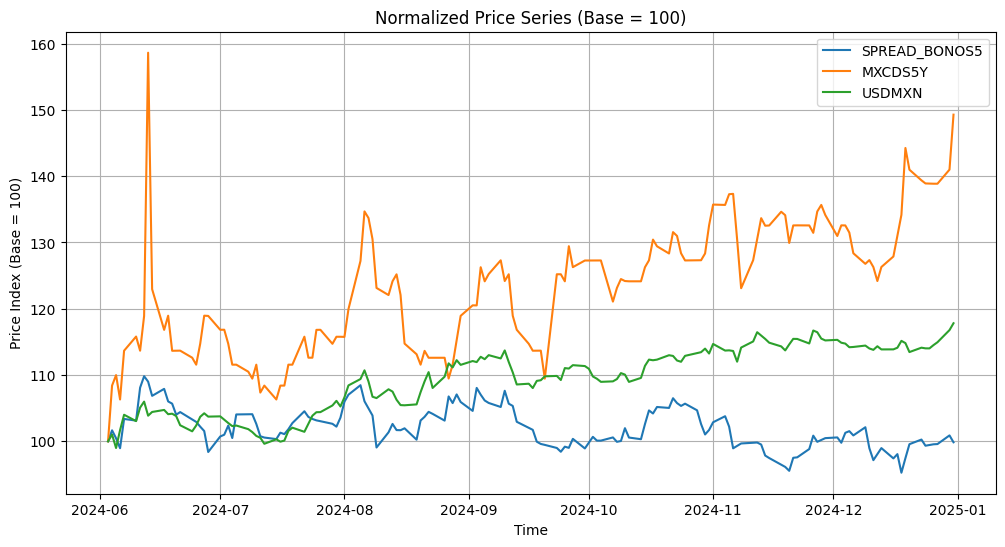

In [158]:

rics = ['SPREAD_BONOS5', 'MXCDS5Y', 'USDMXN']
columnas = ['Diferencia', 'Cierre', 'Cierre']
plot_normalized_timeseries(rics, columnas, from_date='2024-06-01', to_date='2024-12-31')

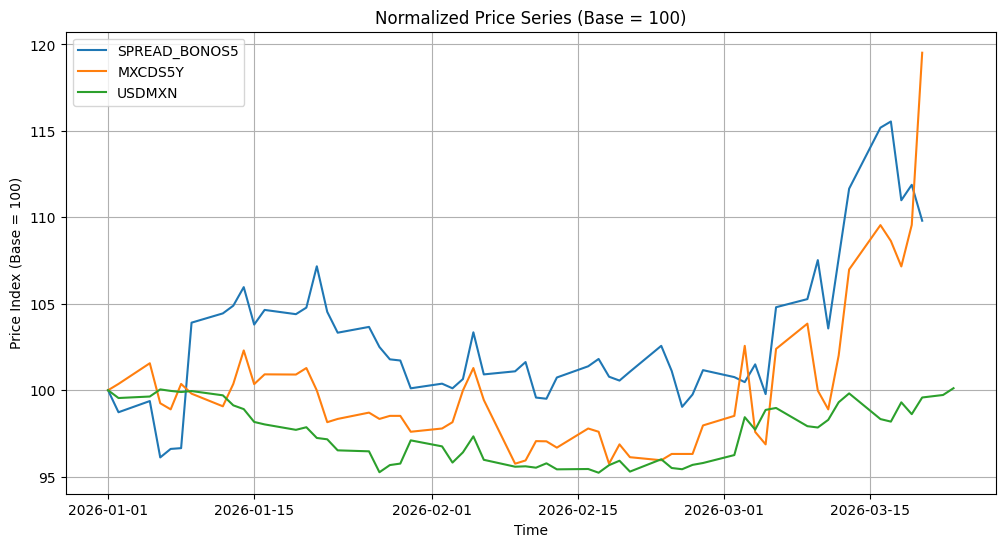

In [ ]:
from financial_risk_analysis.macro_analysis.macro_tools import plot_normalized_timeseries
rics = ['SPREAD_BONOS5', 'MXCDS5Y', 'USDMXN']
columnas = ['Diferencia', 'Cierre', 'Cierre']
plot_normalized_timeseries(rics, columnas, from_date='2026-01-01')

Con esto podríamos decir que analizamos la fortaleza del dolar frente al peso mexicano...
Pero y si queremos ver la fortaleza del dolar en general es decir DXY... 
Lo podemos lograr con esta misma idea y función pero ahora sobre otros activos

GOLD + NASDAQ
VS
DXY + TXN

### NASDAQ
El NASDAQ (National Association of Securities Dealers Automated Quotations) es la segunda bolsa de valores electrónica y automatizada más grande de Estados Unidos y del mundo, con sede en Nueva York. Se caracteriza por albergar principalmente empresas de alta tecnología, informática, telecomunicaciones y biotecnología, funcionando totalmente en red sin un parqué físico.
**Índices Principales:**
* NASDAQ Composite: Incluye casi todas las acciones cotizadas en esta bolsa.
* NASDAQ-100: Agrupa a las 100 empresas no financieras más grandes y activas, siendo un referente de la "nueva economía".

### USDMXN y DXY
USDMXN NO sigue al DXY cuando:
* Hay carry alto en MXN
* Flujos entran a México
PERO sí se alinea cuando:
* Se rompe el “carry trade”
Ejemplo:
* Volatilidad ALTA
* Yields US ALTA
* Riesgo global ALTA
Entonces:
* Salen flujos de MXN
* USDMXN sube MÁS que DXY

**LA EXPECTATIVA EN ESTE TIPO DE ANÁLISIS PODRÍAN AYUDAR A MARCAR UN HORIZONTE MAS ROBUSTO.**

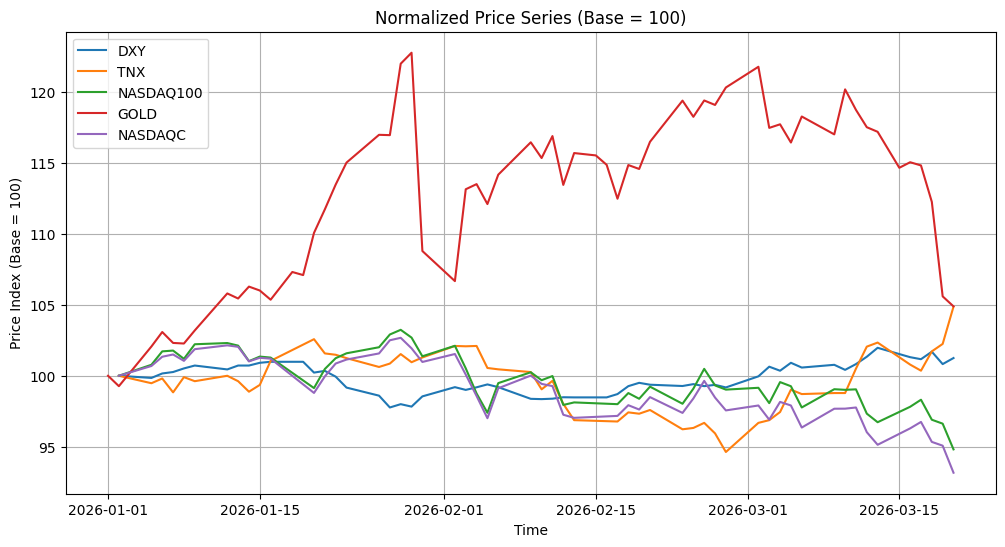

In [ ]:
from financial_risk_analysis.macro_analysis.macro_tools import plot_normalized_timeseries
rics = ['DXY', 'TNX', 'NASDAQ100', 'GOLD', 'NASDAQC']
columnas = ['Cierre', 'Cierre', 'Cierre', 'Cierre', 'Cierre']
plot_normalized_timeseries(rics, columnas, from_date='2026-01-01')

# Oferta moentaria - M1, M2, M3, M4


# Análisis extranjero -> inversiones en bonos, dinero circulando